In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"asmaaoraby","key":"d25f72abf6bc43c7ca1b172409db46c7"}'}

In [3]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("Kaggle API key set up!")

Kaggle API key set up!


In [4]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
print("Download done!")

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
 90% 141M/157M [00:00<00:00, 1.46GB/s]
100% 157M/157M [00:00<00:00, 1.42GB/s]
Download done!


In [5]:
import zipfile
with zipfile.ZipFile("brain-tumor-mri-dataset.zip", "r") as z:
    z.extractall("brain_mri")
print("Extracted!")

import os
for folder in os.listdir("brain_mri"):
    print(" -", folder)

Extracted!
 - Testing
 - Training


In [6]:
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [7]:
IMG_SIZE = (299, 299)
BATCH    = 32
DATA_DIR = "brain_mri"
CLASSES  = ["glioma", "meningioma", "notumor", "pituitary"]

In [8]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
).flow_from_directory(
    DATA_DIR + "/Training",
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical"
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    DATA_DIR + "/Testing",
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

print("Classes:", train_gen.class_indices)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


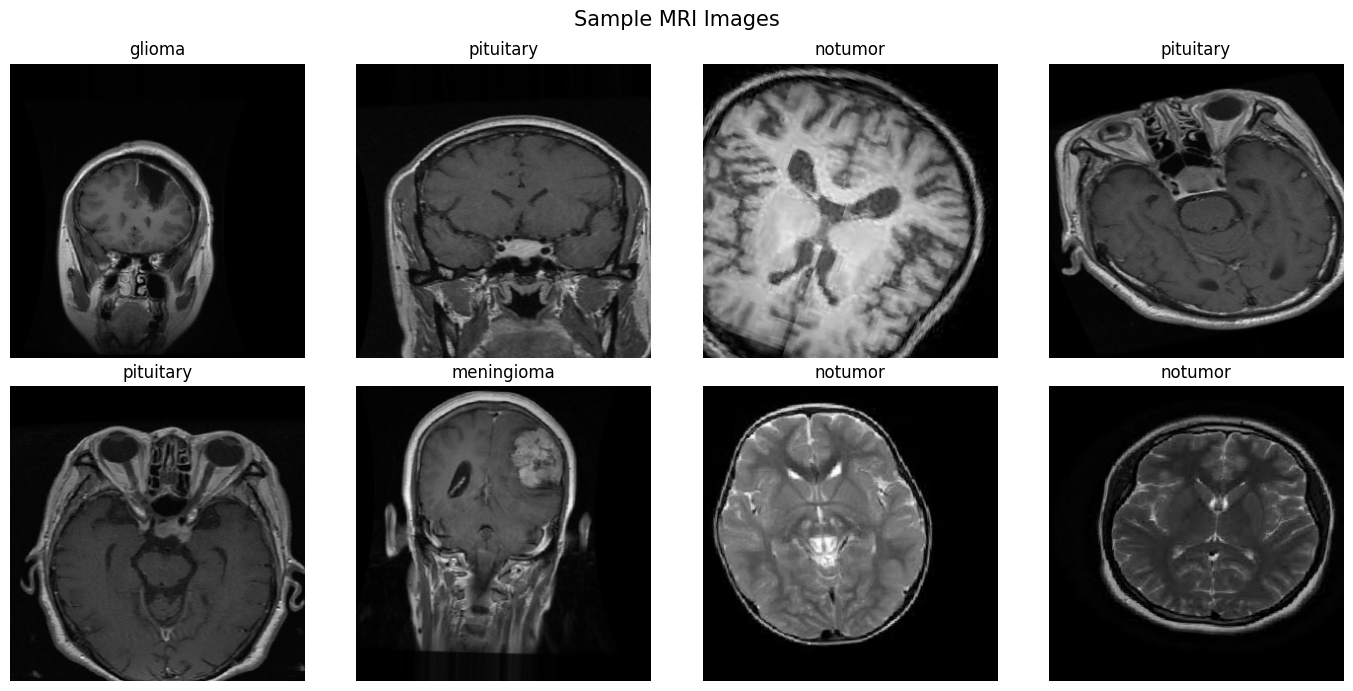

In [9]:
images, labels = next(train_gen)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.set_title(CLASSES[np.argmax(labels[i])], fontsize=12)
    ax.axis("off")
plt.suptitle("Sample MRI Images", fontsize=15)
plt.tight_layout()
plt.show()

In [10]:
#build model
base = Xception(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
base.trainable = False

inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation="relu")(x)
x       = layers.Dropout(0.5)(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation="softmax")(x)

model = models.Model(inputs, outputs)
model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,419,436 (81.71 MB)

 Trainable params: 557,956 (2.13 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [11]:
model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, verbose=1)
]

h1 = model.fit(train_gen, epochs=10, validation_data=test_gen, callbacks=callbacks)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.6481 - loss: 0.8363 - val_accuracy: 0.8131 - val_loss: 0.5290 - learning_rate: 0.0010
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 167s 955ms/step - accuracy: 0.8235 - loss: 0.4652 - val_accuracy: 0.8263 - val_loss: 0.5223 - learning_rate: 0.0010
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 168s 958ms/step - accuracy: 0.8552 - loss: 0.3879 - val_accuracy: 0.8400 - val_loss: 0.5107 - learning_rate: 0.0010
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 166s 950ms/step - accuracy: 0.8653 - loss: 0.3752 - val_accuracy: 0.8394 - val_loss: 0.4795 - learning_rate: 0.0010
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 166s 948ms/step - accuracy: 0.8699 - loss: 0.3413 - val_accuracy: 0.8450 - val_loss: 0.4945 - learning_rate: 0.0010
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 166s 950ms/step - accuracy: 0.8680 - loss: 0.3378 - val_accuracy: 0.8650 - val_loss: 0.4095 - learning_rate: 0.0010
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 169s 962ms/step - accuracy:

In [12]:
base.trainable = True

for layer in base.layers:
    layer.trainable = True if "block14" in layer.name else False

model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

h2 = model.fit(train_gen, epochs=15, validation_data=test_gen, callbacks=callbacks)

Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.6398 - loss: 0.9265 - val_accuracy: 0.8281 - val_loss: 0.5228 - learning_rate: 1.0000e-05
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 170s 971ms/step - accuracy: 0.8355 - loss: 0.4508 - val_accuracy: 0.8319 - val_loss: 0.4990 - learning_rate: 1.0000e-05
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 169s 965ms/step - accuracy: 0.8737 - loss: 0.3461 - val_accuracy: 0.8338 - val_loss: 0.4969 - learning_rate: 1.0000e-05
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 169s 967ms/step - accuracy: 0.8906 - loss: 0.3136 - val_accuracy: 0.8425 - val_loss: 0.4850 - learning_rate: 1.0000e-05
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 202s 968ms/step - accuracy: 0.8935 - loss: 0.3003 - val_accuracy: 0.8537 - val_loss: 0.4777 - learning_rate: 1.0000e-05
Epoch 6/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 170s 972ms/step - accuracy: 0.9077 - loss: 0.2781 - val_accuracy: 0.8581 - val_loss: 0.4656 - learning_rate: 1.0000e-05
Epoch 7/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 170

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 275ms/step - accuracy: 0.7960 - loss: 0.7553
Test Accuracy : 88.81%
Test Loss     : 0.4056
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 279ms/step
              precision    recall  f1-score   support

      glioma       0.94      0.71      0.81       400
  meningioma       0.82      0.86      0.84       400
     notumor       0.89      0.99      0.94       400
   pituitary       0.92      0.98      0.95       400

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.88      1600
weighted avg       0.89      0.89      0.88      1600



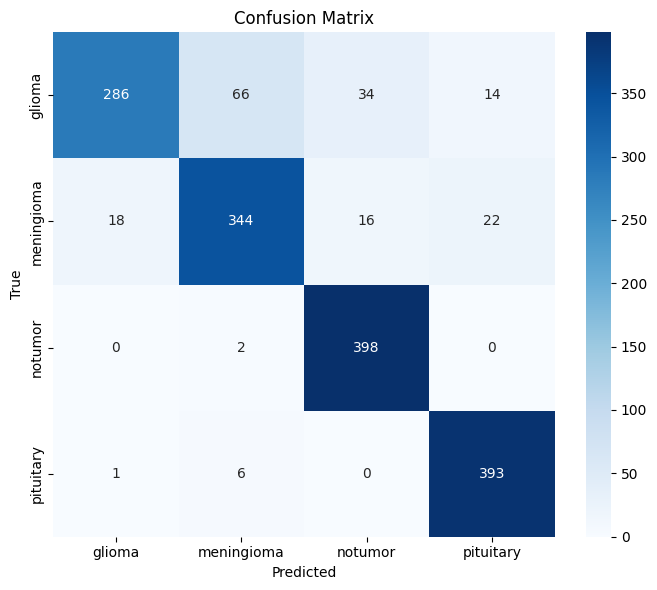

In [14]:
loss, acc = model.evaluate(test_gen)
print(f"Test Accuracy : {acc*100:.2f}%")
print(f"Test Loss     : {loss:.4f}")

test_gen.reset()
y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = test_gen.classes

print(classification_report(y_true, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Confusion Matrix")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

Image picked: brain_mri/Testing/meningioma/Te-me_187.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step


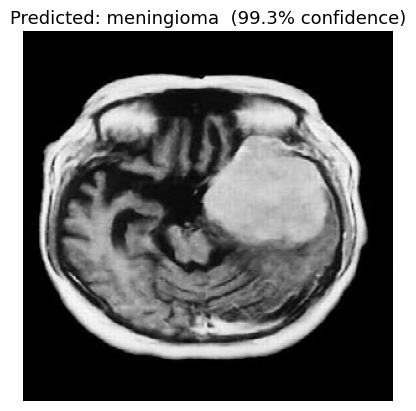

Result    : meningioma
Confidence: 99.32%


In [16]:
from tensorflow.keras.preprocessing import image

#picks a random image
import random, glob
all_images = glob.glob("brain_mri/Testing/**/*.jpg", recursive=True)
img_path   = random.choice(all_images)
print("Image picked:", img_path)

img = image.load_img(img_path, target_size=IMG_SIZE)
x   = image.img_to_array(img) / 255.0
x   = np.expand_dims(x, axis=0)

pred  = model.predict(x)[0]
label = CLASSES[np.argmax(pred)]
conf  = np.max(pred)

plt.imshow(img)
plt.title(f"Predicted: {label}  ({conf:.1%} confidence)", fontsize=13)
plt.axis("off")
plt.show()

print(f"Result    : {label}")
print(f"Confidence: {conf:.2%}")